# Australian Coral Reef

**Exploratory Data Analysis** using *Matplotlib* and *Seaborn* for **visualization**

Description of Data in Dataset

| Column | Description |
|:---|:---|
| `Station ID` | ID of the station where the sample was collected. |
| `MMP_SITE_NAME` | Name of the Marine Monitoring Program (MMP) site where the sample was collected. |
| `LONGITUDE` | Longitude of the sampling site. |
| `LATITUDE` | Latitude of the sampling site. |
| `LOGGER_SERIAL` | Serial number of the data logger that recorded the readings. |
| `SAMPLE_DAY` | Date the sample was collected. |
| `CHL_QA_AVG` | Daily average chlorophyll concentration in the water, measured in µg/L (micrograms per litre). |
| `NTU_QA_AVG` | Daily average turbidity, measured in NTU (Nephelometric Turbidity Units). Turbidity shows how cloudy the water is because of suspended particles. |

## Importing Required Libraries and Importing Dataset

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("data/combined_marine_dataset_3sites.csv") #dataset is imported into df - the pandas DataFrame

## Exploring Dataset

In [14]:
df.head() # first few rows of df

,STATION_ID,MMP_SITE_NAME,LONGITUDE,LATITUDE,LOGGER_SERIAL,SAMPLE_DAY,CHL_QA_AVG,NTU_QA_AVG
0,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-22,1.910,3.901
1,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-23,1.935,3.958
2,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-24,1.867,2.408
3,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-25,2.166,1.352
4,BUR13,Burdekin River mouth mooring,147.5822,-19.5875,1958,2015-03-26,1.911,1.058


### Exploring Numerical Data

In [19]:
df.describe() #summary of numerical data

,LONGITUDE,LATITUDE,LOGGER_SERIAL,CHL_QA_AVG,NTU_QA_AVG
count,7786.000000,7786.000000,7786.000000,7786.000000,7744.000000
mean,147.559106,-19.089235,1620.652453,0.717835,4.148771
std,1.128056,1.404675,1857.961498,0.396201,6.656222
min,145.996300,-20.377900,351.000000,0.035000,0.274000
25%,145.996300,-20.377900,822.000000,0.436000,0.998750
50%,147.582200,-19.587500,842.000000,0.702000,2.020000
75%,148.888400,-16.923200,1329.000000,0.941000,4.747250
max,148.888400,-16.923200,7380.000000,7.965000,117.268000


### Exploring Categorical Data

In [27]:
df["MMP_SITE_NAME"].value_counts()

MMP_SITE_NAME
Burdekin River mouth mooring    3026
Pine                            2548
Fitzroy West                    2212
Name: count, dtype: int64

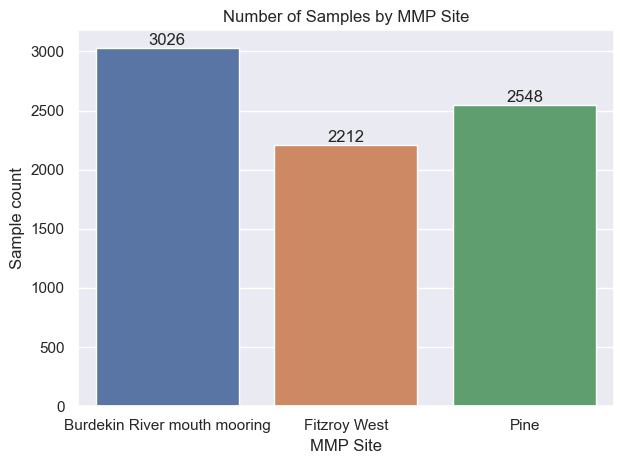

In [116]:
#visualizing the above result using a countplot (basically a histogram)
sns.set_theme(style="darkgrid", palette="deep")

ax = sns.countplot(
    data=df,
    x="MMP_SITE_NAME",
    hue="MMP_SITE_NAME",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Samples by MMP Site")
plt.xlabel("MMP Site")
plt.ylabel("Sample count")
plt.tight_layout()
plt.show()

In [141]:
counts = df.groupby(["STATION_ID", "LOGGER_SERIAL"]).size().reset_index(name="count")
print(counts)

   STATION_ID  LOGGER_SERIAL  count
0       BUR13            351    167
1       BUR13            818    163
2       BUR13            819     77
3       BUR13            822    156
4       BUR13            824    166
5       BUR13            826    118
6       BUR13            828    177
7       BUR13            837    115
8       BUR13            838    133
9       BUR13            844     86
10      BUR13            846    182
11      BUR13           1043    274
12      BUR13           1091    115
13      BUR13           1329     61
14      BUR13           1464    192
15      BUR13           1729    118
16      BUR13           1958    227
17      BUR13           2332    224
18      BUR13           6668    128
19      BUR13           6703    147
20    Fitzroy            351    118
21    Fitzroy            816    106
22    Fitzroy            817    259
23    Fitzroy            819     45
24    Fitzroy            826    190
25    Fitzroy            827    147
26    Fitzroy            828

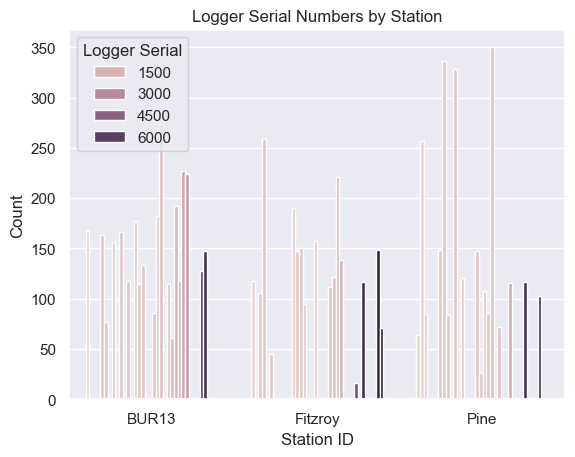

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = df.groupby(["STATION_ID", "LOGGER_SERIAL"]).size().reset_index(name="count")

sns.barplot(
    data=counts,
    x="STATION_ID",
    y="count",
    hue="LOGGER_SERIAL"
)

plt.title("Logger Serial Numbers by Station")
plt.xlabel("Station ID")
plt.ylabel("Count")
plt.legend(title="Logger Serial")
plt.show()

<span style="color:red"><strong>Many different Data Loggers across the 3 Sites, refer to Value Counts above to get a clear, full picture, Visualization of a large categorical variables is difficult in this way. The heatmap below may be useful to check common Data Loggers across sites.</strong></span>

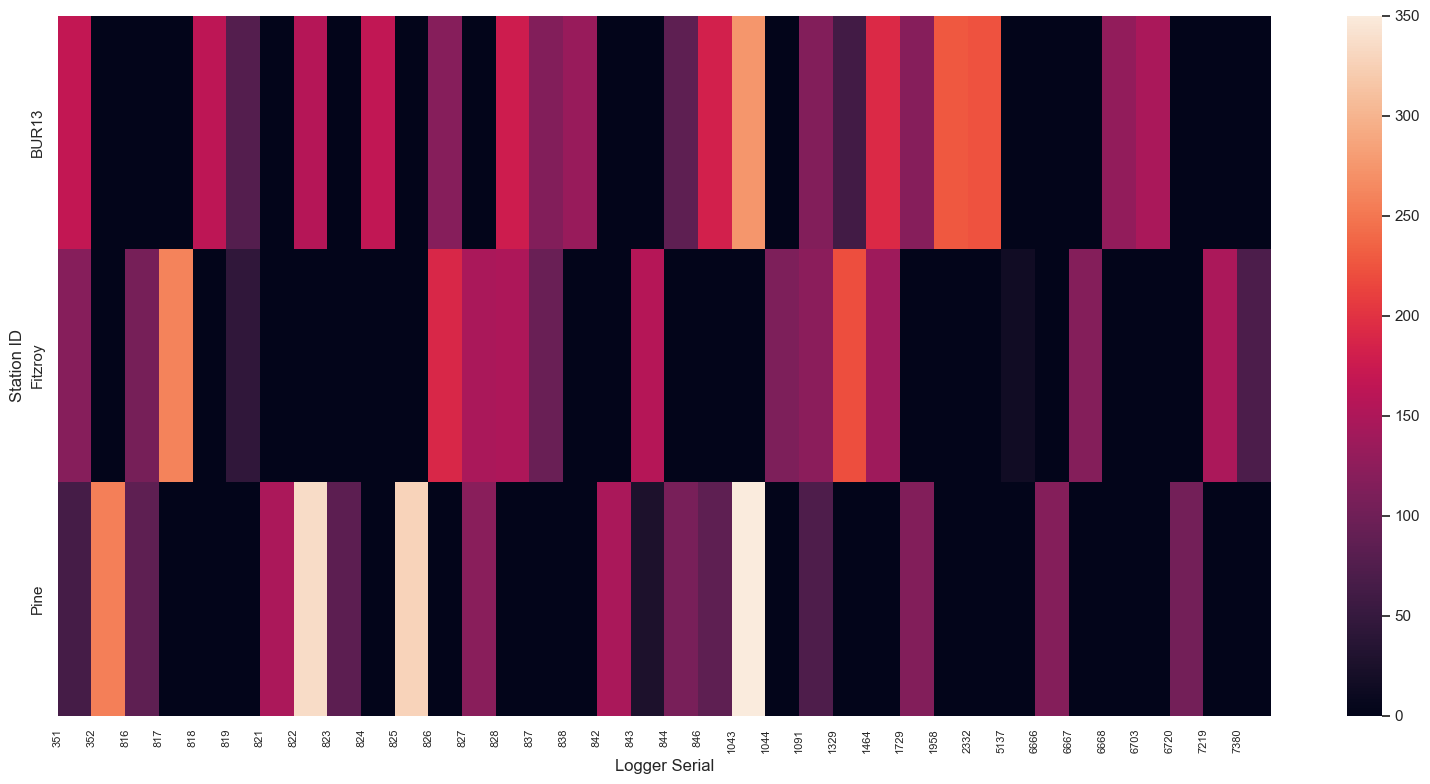

In [152]:
plt.figure(figsize=(16, 8))

table = pd.crosstab(df["STATION_ID"], df["LOGGER_SERIAL"])

sns.heatmap(table)

plt.xticks(
    ticks=range(len(table.columns)),
    labels=table.columns,
    rotation=90,
    fontsize=8
)

plt.xlabel("Logger Serial")
plt.ylabel("Station ID")
plt.tight_layout()
plt.show()

<span style="color:red"><strong>From this heatmap, you can see that Devices with serial nos: 351, 816, 819, 846, 1729 are among some of the Serials of devices that are available at two or more sites.</strong></span>